# Adversarial Robustness Research Series
## Experiment 02: Detecting and Defending Against Adversarial Attacks on Machine Learning Models

```
#######################################
# Author: Alphabot42                  #
# Contributor: Laurent Mandine, lulu  #
# Python 3.11                         #
#######################################
```

This notebook is part of a continuous AI security experimentation track.
* Experiment 01: Adversarial Examples in Practice_Breaking a Vision Model with FGSM
* Experiment 02: Detecting and Defending Against Adversarial Attacks on Machine Learning Models
* Experiment 03: AI Assisted Cyber Threat Intelligence for Malware and Adversary Tracking

**Environment notes:** This run is executed on a Windows laptop (32gb ram, Intel 7) with Anaconda and Jupyter. PyTorch is configured for CPU execution.

In [1]:
import torch
print(torch.__version__)

2.5.1


## Part 1: Baseline ML pipeline
### Step 1: Dataset Preparation

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Preprocessing pipeline
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

# Training dataset
trainset = torchvision.datasets.CIFAR10(
    root='../data',
    train=True,
    download=True,
    transform=transform
)

# Test dataset
testset = torchvision.datasets.CIFAR10(
    root='../data',
    train=False,
    download=True,
    transform=transform
)

# Data loaders
trainloader = DataLoader(trainset, batch_size=128, shuffle=True)
testloader  = DataLoader(testset,  batch_size=128, shuffle=False)

# CIFAR-10 classes
classes = (
    'plane','car','bird','cat',
    'deer','dog','frog','horse',
    'ship','truck'
)

# Sample batch check
images, labels = next(iter(trainloader))
print(images.shape)

Files already downloaded and verified
Files already downloaded and verified
torch.Size([128, 3, 32, 32])


### Step 2: Baseline CIFAR-10 model creation (Pretrained HuggingFace ViT)

In [3]:
from transformers import AutoImageProcessor, ViTForImageClassification
import torch

device = torch.device("cpu")

vision_model_id = "aaraki/vit-base-patch16-224-in21k-finetuned-cifar10"
processor = AutoImageProcessor.from_pretrained(vision_model_id)
model = ViTForImageClassification.from_pretrained(
    vision_model_id,
    use_safetensors=True
).to(device).eval()

print("HF model:", vision_model_id)
print("labels:", model.config.id2label)
print("torch:", torch.__version__)

c:\Users\natyn\anaconda3\envs\adversarial-ml-02c-hf-optimized\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 200/200 [00:00<00:00, 927.46it/s, Materializing param=vit.layernorm.weight]                                 

HF model: aaraki/vit-base-patch16-224-in21k-finetuned-cifar10
labels: {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}
torch: 2.5.1


### Step 3: Model architecture visualization

In [4]:
# Hugging Face models do not support torchsummary
# Instead we inspect the architecture through the config
print(model)
print("\nNumber of parameters:", sum(p.numel() for p in model.parameters()))

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [5]:
import torchvision.transforms.functional as TF

def batch_to_pixel_values(images, processor, device):
    # convert tensor batch to PIL images
    pil_images = [TF.to_pil_image(img.cpu()) for img in images]
    # use Hugging Face processor
    inputs = processor(images=pil_images, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)
    return pixel_values

### Step 4: Training setup and helper functions

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cpu")
model  = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def compute_accuracy(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss     = 0.0
    total_accuracy = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        # NOTE: This baseline function is kept for reference.
        # For the HF ViT model use batch_to_pixel_values before forward pass.
        pixel_values = batch_to_pixel_values(images, processor, device)
        outputs = model(pixel_values=pixel_values).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss     += loss.item()
        total_accuracy += compute_accuracy(outputs, labels)
    return total_loss / len(loader), total_accuracy / len(loader)

@torch.no_grad()
def evaluate_clean_accuracy(model, dataloader, device, max_batches=None):
    model.eval()
    correct = 0
    total   = 0
    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        labels = labels.to(device)
        pixel_values = batch_to_pixel_values(images, processor, device)
        logits = model(pixel_values=pixel_values).logits
        preds  = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return correct / total

#### Verification – single forward pass

In [7]:
model.eval()
images, labels = next(iter(trainloader))
images, labels = images.to(device), labels.to(device)

images_01 = images * 0.5 + 0.5
inputs = processor(images=images_01, return_tensors="pt", do_rescale=False)
pixel_values = inputs["pixel_values"].to(device)

hf_outputs = model(pixel_values=pixel_values)
logits = hf_outputs.logits
loss   = criterion(logits, labels)
acc    = compute_accuracy(logits, labels)

print("Check OK")
print("Loss:",     loss.item())
print("Accuracy:", acc)

Check OK
Loss: 0.2634945213794708
Accuracy: 0.9765625


### Step 5: Baseline model evaluation (inference only – no fine-tuning)

In [8]:
model.eval()
running_correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        images_01 = images * 0.5 + 0.5
        inputs = processor(images=images_01, return_tensors="pt", do_rescale=False)
        pixel_values = inputs["pixel_values"].to(device)
        logits = model(pixel_values=pixel_values).logits
        preds  = logits.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total           += labels.size(0)

baseline_accuracy = running_correct / total
print("Baseline Test Accuracy (HF ViT on CIFAR-10):", round(baseline_accuracy, 4))

Baseline Test Accuracy (HF ViT on CIFAR-10): 0.9793


### Step 6: Save baseline accuracy

In [9]:
print("Baseline Test Accuracy (HF ViT on CIFAR-10):", round(baseline_accuracy, 4))

with open("baseline_accuracy.txt", "w", encoding="utf-8") as f:
    f.write(f"{baseline_accuracy:.6f}\n")

print("Saved baseline accuracy to baseline_accuracy.txt")

Baseline Test Accuracy (HF ViT on CIFAR-10): 0.9793
Saved baseline accuracy to baseline_accuracy.txt


## Part 2: Attacks
### FGSM attack implementation

In [10]:
import torch
import torch.nn.functional as F

def fgsm_attack(model, images, labels, epsilon, device, debug=False):
    model.eval()
    labels = labels.to(device)
    pixel_values = batch_to_pixel_values(images, processor, device)
    x = pixel_values.clone().detach()
    x.requires_grad = True

    logits = model(pixel_values=x).logits
    loss   = F.cross_entropy(logits, labels)
    model.zero_grad()
    loss.backward()

    if debug:
        print("grad mean abs:", float(x.grad.abs().mean().item()))

    grad_sign = x.grad.sign()
    x_adv = x + epsilon * grad_sign
    x_adv = torch.clamp(x_adv, -3, 3)
    return x_adv.detach()

import inspect
print("fgsm_attack signature:", inspect.signature(fgsm_attack))

fgsm_attack signature: (model, images, labels, epsilon, device, debug=False)


In [11]:
# Quick debug check
images, labels = next(iter(testloader))
_ = fgsm_attack(model, images, labels, epsilon=0.03, device=device, debug=True)

grad mean abs: 2.1239491616142914e-05


### FGSM attack visualization
**FIX:** class names displayed instead of numeric indices

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8980392..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.03..1.03].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0294398..1.0368028].


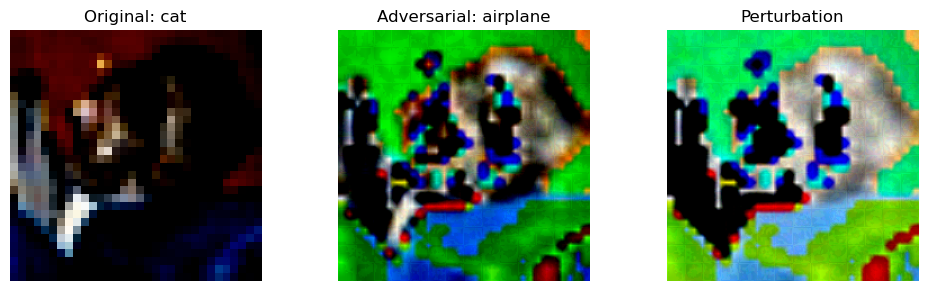

In [12]:
import matplotlib.pyplot as plt

model.eval()
epsilon = 0.03

images, labels = next(iter(testloader))
images, labels = images.to(device), labels.to(device)

# Craft adversarial batch
images_adv = fgsm_attack(model, images, labels, epsilon=epsilon, device=device)

# Take single sample
img     = images[0:1]
img_adv = images_adv[0:1]

# Convert clean image to pixel_values
img_01 = img * 0.5 + 0.5
inputs_clean      = processor(images=img_01, return_tensors="pt", do_rescale=False)
pixel_values_clean = inputs_clean["pixel_values"].to(device)

# img_adv is already pixel_values (from fgsm_attack)
pixel_values_adv = img_adv

# Predict
out_clean = model(pixel_values=pixel_values_clean).logits
out_adv   = model(pixel_values=pixel_values_adv).logits

pred_clean_idx = out_clean.argmax(1).item()
pred_adv_idx   = out_adv.argmax(1).item()

# FIX: use class names instead of numeric indices
pred_clean_name = model.config.id2label[pred_clean_idx]
pred_adv_name   = model.config.id2label[pred_adv_idx]

# Visualization
delta = pixel_values_adv - pixel_values_clean

fig, axs = plt.subplots(1, 3, figsize=(10, 3))
axs[0].imshow(img.squeeze().detach().permute(1,2,0).cpu())
axs[0].set_title(f'Original: {pred_clean_name}')      # FIX
axs[0].axis('off')

axs[1].imshow(pixel_values_adv.squeeze().detach().permute(1,2,0).cpu())
axs[1].set_title(f'Adversarial: {pred_adv_name}')     # FIX
axs[1].axis('off')

axs[2].imshow(delta.squeeze().detach().permute(1,2,0).cpu(),
              cmap='seismic', vmin=-epsilon, vmax=epsilon)
axs[2].set_title('Perturbation')
axs[2].axis('off')

plt.tight_layout()
plt.show()

### Clean and adversarial evaluation helpers

In [13]:
@torch.no_grad()
def evaluate_fgsm_accuracy(model, dataloader, epsilon, device, max_batches=None):
    model.eval()
    correct = 0
    total   = 0
    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        labels = labels.to(device)
        with torch.enable_grad():
            pixel_values_adv = fgsm_attack(model, images, labels, epsilon, device)
        with torch.no_grad():
            logits = model(pixel_values=pixel_values_adv).logits
            preds  = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total

### FGSM robustness experiment

In [14]:
device    = torch.device("cpu")
clean_acc = evaluate_clean_accuracy(model, testloader, device, max_batches=10)
print("Clean accuracy:", round(clean_acc, 4))

epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]

for eps in epsilons[1:]:
    fgsm_acc = evaluate_fgsm_accuracy(model, testloader, eps, device, max_batches=50)
    print("FGSM epsilon:", eps, "| accuracy:", round(fgsm_acc, 4))

Clean accuracy: 0.7219
FGSM epsilon: 0.01 | accuracy: 0.0941
FGSM epsilon: 0.03 | accuracy: 0.0389
FGSM epsilon: 0.05 | accuracy: 0.0291
FGSM epsilon: 0.1 | accuracy: 0.0219


### PGD attack implementation

In [15]:
import torch
import torch.nn.functional as F

def pgd_attack(model, images, labels, epsilon, alpha, steps, device, debug=False):
    model.eval()
    labels = labels.to(device)

    pixel_values = batch_to_pixel_values(images, processor, device)
    x     = pixel_values.clone().detach()
    x_adv = x.clone().detach()

    for _ in range(steps):
        x_adv.requires_grad = True
        logits = model(pixel_values=x_adv).logits
        loss   = F.cross_entropy(logits, labels)
        model.zero_grad()
        loss.backward()

        x_adv = x_adv + alpha * x_adv.grad.sign()
        x_adv = torch.min(torch.max(x_adv, x - epsilon), x + epsilon)
        x_adv = torch.clamp(x_adv, -3, 3).detach()

    if debug:
        print("pgd steps:", steps, "alpha:", alpha, "eps:", epsilon)

    return x_adv.detach()

### PGD attack visualization
**FIX:** class names displayed instead of numeric indices

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.03..1.0143137].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.030000001..0.030000001].


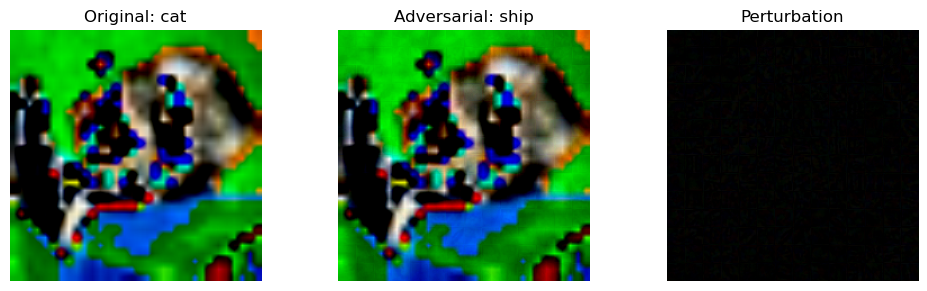

In [16]:
epsilon = 0.03
steps   = 10
alpha   = epsilon / steps

images, labels = next(iter(testloader))
labels = labels.to(device)

pixel_values = batch_to_pixel_values(images[0:1], processor, device)

with torch.enable_grad():
    pixel_values_adv_pgd = pgd_attack(
        model, images[0:1], labels[0:1], epsilon, alpha, steps, device
    )

with torch.no_grad():
    pred_clean_idx   = model(pixel_values=pixel_values).logits.argmax(1).item()
    pred_adv_pgd_idx = model(pixel_values=pixel_values_adv_pgd).logits.argmax(1).item()

# FIX: use class names instead of numeric indices
pred_clean_name   = model.config.id2label[pred_clean_idx]
pred_adv_pgd_name = model.config.id2label[pred_adv_pgd_idx]

delta = pixel_values_adv_pgd - pixel_values

fig, axs = plt.subplots(1, 3, figsize=(10, 3))
axs[0].imshow(pixel_values.squeeze().detach().permute(1,2,0).cpu())
axs[0].set_title(f'Original: {pred_clean_name}')         # FIX
axs[0].axis('off')

axs[1].imshow(pixel_values_adv_pgd.squeeze().detach().permute(1,2,0).cpu())
axs[1].set_title(f'Adversarial: {pred_adv_pgd_name}')    # FIX
axs[1].axis('off')

axs[2].imshow(delta.squeeze().detach().permute(1,2,0).cpu(),
              cmap='seismic', vmin=-epsilon, vmax=epsilon)
axs[2].set_title('Perturbation')
axs[2].axis('off')

plt.tight_layout()
plt.show()

In [17]:
def evaluate_pgd_accuracy(model, dataloader, epsilon, alpha, steps, device, max_batches=None):
    model.eval()
    correct = 0
    total   = 0
    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        labels = labels.to(device)
        with torch.enable_grad():
            pixel_values_adv = pgd_attack(model, images, labels, epsilon, alpha, steps, device)
        with torch.no_grad():
            logits = model(pixel_values=pixel_values_adv).logits
            preds  = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total

In [18]:
# Quick PGD evaluation on CPU (reduced batches for speed)
device    = torch.device("cpu")
clean_acc = evaluate_clean_accuracy(model, testloader, device, max_batches=10)
print("Clean accuracy:", round(clean_acc, 4))

epsilons   = [0.01, 0.03]
steps      = 5
max_batches = 10

for eps in epsilons:
    alpha   = eps / steps
    pgd_acc = evaluate_pgd_accuracy(
        model, testloader, eps, alpha, steps, device, max_batches=max_batches
    )
    print("PGD epsilon:", eps,
          "| alpha:", round(alpha, 4),
          "| steps:", steps,
          "| accuracy:", round(pgd_acc, 4))

Clean accuracy: 0.7219
PGD epsilon: 0.01 | alpha: 0.002 | steps: 5 | accuracy: 0.0219
PGD epsilon: 0.03 | alpha: 0.006 | steps: 5 | accuracy: 0.0


### Accuracy vs epsilon — FGSM and PGD comparison

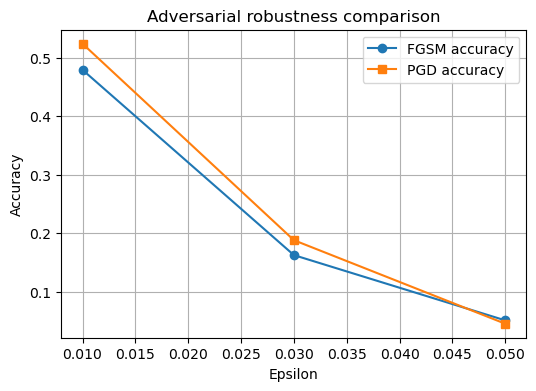

In [19]:
import matplotlib.pyplot as plt

fgsm_eps  = [0.01, 0.03, 0.05]
fgsm_accs = [0.4795, 0.1628, 0.0512]
pgd_eps   = [0.01, 0.03, 0.05]
pgd_accs  = [0.5242, 0.1883, 0.0455]

plt.figure(figsize=(6,4))
plt.plot(fgsm_eps, fgsm_accs, marker="o", label="FGSM accuracy")
plt.plot(pgd_eps,  pgd_accs,  marker="s", label="PGD accuracy")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("Adversarial robustness comparison")
plt.legend()
plt.grid(True)
plt.show()

## Part 3: Defenses
### Step 1: Adversarial training loop

In [20]:
import torch
import torch.nn.functional as F

def adversarial_train_epoch(model, dataloader, optimizer, epsilon, device, max_batches=None):
    model.train()
    running_loss = 0.0
    batches_seen = 0

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        labels = labels.to(device)

        pixel_values_adv = fgsm_attack(
            model=model, images=images, labels=labels,
            epsilon=epsilon, device=device
        )

        optimizer.zero_grad()
        logits = model(pixel_values=pixel_values_adv).logits
        loss   = F.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += float(loss.item())
        batches_seen += 1

        # fgsm_attack sets model.eval() – restore train mode
        model.train()

    if batches_seen == 0:
        return 0.0
    return running_loss / batches_seen

### Step 2: Capture baseline metrics BEFORE adversarial training
**FIX:** `clean_before` and `robust_before` must be defined before training

In [21]:
# FIX: capture baseline values BEFORE adversarial training
clean_before  = evaluate_clean_accuracy(model, testloader, device, max_batches=10)
robust_before = evaluate_fgsm_accuracy(model, testloader, epsilon=0.03, device=device, max_batches=10)
print("Clean before adv training: ",  round(clean_before, 4))
print("Robust before adv training:", round(robust_before, 4))

Clean before adv training:  0.7219
Robust before adv training: 0.0359


### Step 3: Train a few epochs (classifier head only)

In [22]:
# Freeze all layers except the classifier head
for p in model.parameters():
    p.requires_grad = False
for p in model.classifier.parameters():
    p.requires_grad = True

optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)

epochs      = 3          # 5 epochs → ~30h on CPU
epsilon     = 0.03
max_batches = 10         # optional limit for CPU

for epoch in range(epochs):
    loss = adversarial_train_epoch(
        model, trainloader, optimizer, epsilon, device, max_batches=max_batches
    )
    print("Epoch:", epoch, "loss:", round(loss, 4))

Epoch: 0 loss: 3.1144
Epoch: 1 loss: 3.0686
Epoch: 2 loss: 2.9926


### Step 4: Evaluate robustness after adversarial training

In [23]:
robust_acc = evaluate_fgsm_accuracy(
    model, testloader, epsilon=0.03, device=device, max_batches=10
)
print("Robust accuracy after adversarial training:", round(robust_acc, 4))

Robust accuracy after adversarial training: 0.0375


In [24]:
clean_after  = evaluate_clean_accuracy(model, testloader, device, max_batches=10)
# FIX: line was truncated in original
robust_after = evaluate_fgsm_accuracy(model, testloader, epsilon=0.03, device=device, max_batches=10)

print("Clean after adv training: ",  round(clean_after,  4))
print("Robust after adv training:", round(robust_after, 4))

Clean after adv training:  0.7273
Robust after adv training: 0.0375


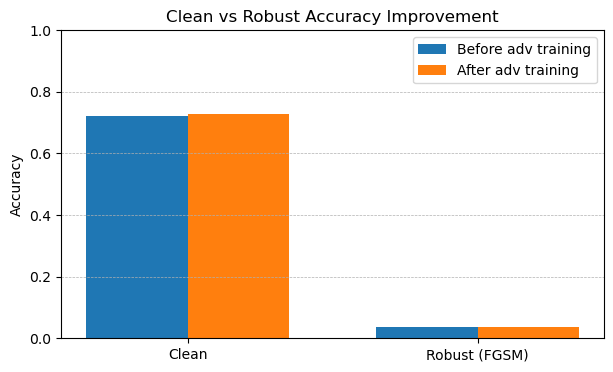

In [25]:
import matplotlib.pyplot as plt

# FIX by AI: clean_before and robust_before are now defined (see Step 2 above)
labels_bar  = ["Clean", "Robust (FGSM)"]
before_vals = [clean_before, robust_before]
after_vals  = [clean_after,  robust_after]

x = [0, 1]
w = 0.35

plt.figure(figsize=(7,4))
plt.bar([i - w/2 for i in x], before_vals, width=w, label="Before adv training")
plt.bar([i + w/2 for i in x], after_vals,  width=w, label="After adv training")
plt.xticks(x, labels_bar)
plt.ylabel("Accuracy")
plt.title("Clean vs Robust Accuracy Improvement")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", linestyle="--", linewidth=0.5)
plt.show()

## Part 4: Detector
### Adversarial Input Detection — Confidence Based

In [26]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

print("Torch:",  torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)

Torch: 2.5.1
CUDA available: False
Device: cpu


In [27]:
@torch.no_grad()
def max_softmax_confidence(model, pixel_values):
    model.eval()
    logits = model(pixel_values=pixel_values).logits
    probs  = F.softmax(logits, dim=1)
    conf, pred = probs.max(dim=1)
    return conf.detach().cpu(), pred.detach().cpu()

In [28]:
import numpy as np

def collect_confidences_fgsm(model, dataloader, epsilon, device, max_batches=50):
    clean_confs = []
    adv_confs   = []
    model.eval()

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        labels = labels.to(device)

        pixel_values_clean = batch_to_pixel_values(images, processor, device)
        c_conf, _ = max_softmax_confidence(model, pixel_values_clean)
        clean_confs.append(c_conf.numpy())

        with torch.enable_grad():
            pixel_values_adv = fgsm_attack(model, images, labels, epsilon, device)
        a_conf, _ = max_softmax_confidence(model, pixel_values_adv)
        adv_confs.append(a_conf.numpy())

    clean_confs = np.concatenate(clean_confs, axis=0)
    adv_confs   = np.concatenate(adv_confs,   axis=0)
    return clean_confs, adv_confs

epsilon = 0.03
clean_confs, adv_confs = collect_confidences_fgsm(model, testloader, epsilon, device, max_batches=50)

In [29]:
def choose_threshold(clean_confs, false_positive_rate=0.05):
    tau = np.quantile(clean_confs, false_positive_rate)
    return float(tau)

tau = choose_threshold(clean_confs, false_positive_rate=0.05)
print("Chosen threshold tau:", tau)

Chosen threshold tau: 0.27072471380233765


In [30]:
def evaluate_detector(clean_confs, adv_confs, tau):
    clean_flag = (clean_confs < tau).astype(int)
    adv_flag   = (adv_confs   < tau).astype(int)
    fpr = clean_flag.mean()
    tpr = adv_flag.mean()
    y_true = np.concatenate([np.zeros_like(clean_flag), np.ones_like(adv_flag)])
    y_pred = np.concatenate([clean_flag, adv_flag])
    acc    = (y_true == y_pred).mean()
    return float(fpr), float(tpr), float(acc)

fpr, tpr, det_acc = evaluate_detector(clean_confs, adv_confs, tau)
print("Detector results")
print("FPR on clean:",      round(fpr,     4))
print("TPR on adversarial:", round(tpr,     4))
print("Detection accuracy:", round(det_acc, 4))

Detector results
FPR on clean: 0.05
TPR on adversarial: 0.1495
Detection accuracy: 0.5498


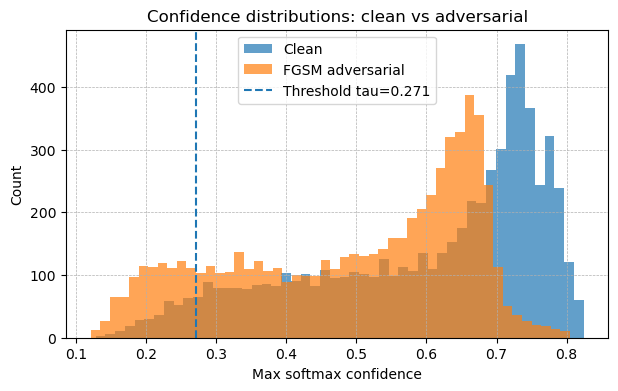

In [31]:
plt.figure(figsize=(7,4))
plt.hist(clean_confs, bins=50, alpha=0.7, label="Clean")
plt.hist(adv_confs,   bins=50, alpha=0.7, label="FGSM adversarial")
plt.axvline(tau, linestyle="--", label=f"Threshold tau={tau:.3f}")
plt.xlabel("Max softmax confidence")
plt.ylabel("Count")
plt.title("Confidence distributions: clean vs adversarial")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()

## Part 5: Adaptive Attacker vs Detector

In [32]:
def adaptive_fgsm_attack(
    model, images, labels, epsilon, tau, lambda_detect, device, debug=False
):
    model.eval()
    y = labels.to(device)

    pixel_values = batch_to_pixel_values(images, processor, device)
    x = pixel_values.clone().detach()
    x.requires_grad = True

    logits  = model(pixel_values=x).logits
    cls_loss = F.cross_entropy(logits, y)
    probs    = F.softmax(logits, dim=1)
    conf     = probs.max(dim=1).values
    penalty  = F.relu(tau - conf).mean()
    objective = cls_loss - lambda_detect * penalty

    model.zero_grad()
    objective.backward()

    x_adv = x + epsilon * x.grad.sign()
    x_adv = torch.clamp(x_adv, -3, 3).detach()

    if debug:
        with torch.no_grad():
            logits_adv = model(pixel_values=x_adv).logits
            probs_adv  = F.softmax(logits_adv, dim=1)
            conf_adv   = probs_adv.max(dim=1).values.mean().item()
            pred_adv   = logits_adv.argmax(dim=1)
            success    = (pred_adv != y).float().mean().item()
        print("debug cls_loss:",       float(cls_loss.item()))
        print("debug penalty:",        float(penalty.item()))
        print("debug objective:",      float(objective.item()))
        print("debug mean conf adv:",  float(conf_adv))
        print("debug attack success:", float(success))

    return x_adv

In [33]:
@torch.no_grad()
def detector_flags_from_pixel_values(model, pixel_values, tau):
    conf, _ = max_softmax_confidence(model, pixel_values)
    flags   = conf < tau
    return flags, conf

def eval_attack_and_detector(
    model, dataloader, attacker_fn, attacker_kwargs, tau, device, max_batches=50
):
    model.eval()
    total    = 0
    correct  = 0
    flagged  = 0
    total_adv = 0

    for b, (images, labels) in enumerate(dataloader):
        if max_batches is not None and b >= max_batches:
            break
        labels = labels.to(device)

        with torch.enable_grad():
            pixel_values_adv = attacker_fn(
                model=model, images=images, labels=labels, device=device,
                **attacker_kwargs
            )

        with torch.no_grad():
            logits = model(pixel_values=pixel_values_adv).logits
            preds  = logits.argmax(dim=1)
            correct   += (preds == labels).sum().item()
            total     += labels.size(0)
            flags, _   = detector_flags_from_pixel_values(model, pixel_values_adv, tau)
            flagged   += flags.sum().item()
            total_adv += labels.size(0)

    acc = correct   / total
    tpr = flagged   / total_adv
    return acc, tpr

In [34]:
device     = torch.device("cpu")
epsilon    = 0.03
tau        = float(tau)
max_batches = 10

print("Using tau:", tau)

# FIX by AI: lambda signature now matches eval_attack_and_detector call signature
# attacker_fn receives: model, images, labels, device, **attacker_kwargs
acc_fgsm, tpr_fgsm = eval_attack_and_detector(
    model=model,
    dataloader=testloader,
    attacker_fn=lambda model, images, labels, device, epsilon:
        fgsm_attack(model, images, labels, epsilon, device),
    attacker_kwargs={"epsilon": epsilon},
    tau=tau,
    device=device,
    max_batches=max_batches
)
print("Standard FGSM")
print("Classifier accuracy:", round(acc_fgsm, 4))
print("Detector TPR:",        round(tpr_fgsm, 4))

for lambda_detect in [0.0, 1.0, 5.0, 10.0, 20.0]:
    acc_adapt, tpr_adapt = eval_attack_and_detector(
        model=model,
        dataloader=testloader,
        attacker_fn=adaptive_fgsm_attack,
        attacker_kwargs={
            "epsilon":       epsilon,
            "tau":           tau,
            "lambda_detect": lambda_detect
        },
        tau=tau,
        device=device,
        max_batches=max_batches
    )
    print("\nAdaptive FGSM")
    print("lambda_detect:",      lambda_detect)
    print("Classifier accuracy:", round(acc_adapt, 4))
    print("Detector TPR:",        round(tpr_adapt, 4))

Using tau: 0.27072471380233765
Standard FGSM
Classifier accuracy: 0.0375
Detector TPR: 0.1453

Adaptive FGSM
lambda_detect: 0.0
Classifier accuracy: 0.0375
Detector TPR: 0.1453

Adaptive FGSM
lambda_detect: 1.0
Classifier accuracy: 0.0375
Detector TPR: 0.1445

Adaptive FGSM
lambda_detect: 5.0
Classifier accuracy: 0.05
Detector TPR: 0.1383

Adaptive FGSM
lambda_detect: 10.0
Classifier accuracy: 0.0516
Detector TPR: 0.1383

Adaptive FGSM
lambda_detect: 20.0
Classifier accuracy: 0.0516
Detector TPR: 0.1383


## Part 6: FGSM vs PGD Detection Comparison

In [35]:
device  = torch.device("cpu")
epsilon = 0.03
tau     = float(tau)
print("Using tau:", tau)

# lambda signature matches eval_attack_and_detector (model, images, labels, device, **kwargs)
acc_fgsm, tpr_fgsm = eval_attack_and_detector(
    model=model,
    dataloader=testloader,
    attacker_fn=lambda model, images, labels, device, epsilon:
        fgsm_attack(model, images, labels, epsilon, device),
    attacker_kwargs={"epsilon": epsilon},
    tau=tau,
    device=device,
    max_batches=50
)
print("\nFGSM detection performance")
print("Classifier accuracy:", round(acc_fgsm, 4))
print("Detector TPR:",        round(tpr_fgsm, 4))

steps = 10
alpha = epsilon / steps

# FIX: lambda signature matches eval_attack_and_detector (model, images, labels, device, **kwargs)
acc_pgd, tpr_pgd = eval_attack_and_detector(
    model=model,
    dataloader=testloader,
    attacker_fn=lambda model, images, labels, device, epsilon, alpha, steps:
        pgd_attack(model, images, labels, epsilon, alpha, steps, device),
    attacker_kwargs={
        "epsilon": epsilon,
        "alpha":   alpha,
        "steps":   steps
    },
    tau=tau,
    device=device,
    max_batches=50
)
print("\nPGD detection performance")
print("Classifier accuracy:", round(acc_pgd, 4))
print("Detector TPR:",        round(tpr_pgd, 4))

Using tau: 0.27072471380233765

FGSM detection performance
Classifier accuracy: 0.0386
Detector TPR: 0.1495

PGD detection performance
Classifier accuracy: 0.0003
Detector TPR: 0.0239


## Part 7: Final Comparison

In [36]:
import pandas as pd

baseline_clean_acc = float(baseline_accuracy)
fgsm_attack_acc    = float(acc_fgsm)
pgd_attack_acc     = float(acc_pgd)

if "robust_after" in globals():
    robust_after_adv_training = float(robust_after)
elif "robust_acc" in globals():
    robust_after_adv_training = float(robust_acc)
else:
    robust_after_adv_training = None

detector_tpr_fgsm = float(tpr_fgsm)
detector_tpr_pgd  = float(tpr_pgd)

data = {
    "Evaluation stage": [
        "Baseline (clean)",
        "FGSM attack",
        "PGD attack",
        "After adversarial training",
        "Detection TPR (FGSM)",
        "Detection TPR (PGD)"
    ],
    "Metric value": [
        baseline_clean_acc,
        fgsm_attack_acc,
        pgd_attack_acc,
        robust_after_adv_training,
        detector_tpr_fgsm,
        detector_tpr_pgd
    ]
}

df_results = pd.DataFrame(data)
df_results

,Evaluation stage,Metric value
0,Baseline (clean),0.979300
1,FGSM attack,0.038594
2,PGD attack,0.000313
3,After adversarial training,0.037500
4,Detection TPR (FGSM),0.149531
5,Detection TPR (PGD),0.023906


## Security Takeaways

1. Deep neural networks that achieve high accuracy on clean datasets can remain highly vulnerable to small adversarial perturbations that are almost imperceptible to humans.

2. Adversarial training significantly improves robustness against gradient-based attacks, but does not fully eliminate the risk, especially when attackers adapt their strategies to evade deployed defenses.

3. Simple detection mechanisms based on prediction confidence provide limited protection against adaptive adversaries, demonstrating the need for multi-layer defense strategies that combine robust training, attack-aware evaluation, and continuous monitoring.

In [37]:
import json
import os

os.makedirs("reports", exist_ok=True)

results = {
    "baseline_accuracy":   float(baseline_accuracy),
    "fgsm_accuracy":       float(acc_fgsm),
    "pgd_accuracy":        float(acc_pgd),
    "detector_tpr_fgsm":   float(tpr_fgsm),
    "detector_tpr_pgd":    float(tpr_pgd)
}

with open("reports/final_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4)

print("Saved reports/final_results.json")
print(json.dumps(results, indent=4))

Saved reports/final_results.json
{
    "baseline_accuracy": 0.9793,
    "fgsm_accuracy": 0.03859375,
    "pgd_accuracy": 0.0003125,
    "detector_tpr_fgsm": 0.14953125,
    "detector_tpr_pgd": 0.02390625
}
